In [1]:
from gpt_morpho_analysis import perform_correlation_analysis
import geopandas as gpd


In [2]:
file = "./results/particleFront/measurements_with_building_features_temp.gpkg"
measurements = gpd.read_file(file)


In [3]:
import matplotlib.pyplot as plt

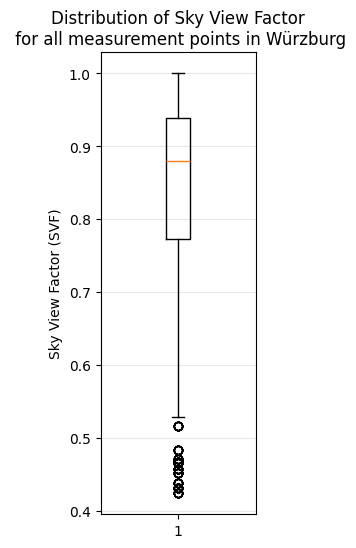

In [4]:
# Create boxplot for sky view factor
fig, ax = plt.subplots(figsize=(2, 6))
ax.boxplot(measurements["svf_ray"].dropna(), vert=True)
ax.set_ylabel("Sky View Factor (SVF)")
ax.set_title("Distribution of Sky View Factor\n for all measurement points in Würzburg")
ax.grid(True, alpha=0.3, axis='y')

In [11]:
measurements["svf_ray"].min()

np.float64(0.4239908207241041)

In [3]:


perform_correlation_analysis(measurements)


CORRELATION ANALYSIS: AIR POLLUTION vs BUILDING MORPHOLOGY
particles_mean_Particles > 0.3um / 0.1L air_particleFront vs nearest_building_height       : r= 0.0774, p=1.5165e-03 **
particles_mean_Particles > 0.3um / 0.1L air_particleFront vs mean_20nn_building_height     : r= 0.0701, p=4.0734e-03 **
particles_mean_Particles > 0.3um / 0.1L air_particleFront vs max_20nn_building_height      : r= 0.0490, p=4.5012e-02 *
particles_mean_Particles > 0.3um / 0.1L air_particleFront vs building_surface_fraction     : r= 0.1135, p=3.1552e-06 ***
particles_mean_Particles > 0.3um / 0.1L air_particleFront vs mean_building_height_in_buffer: r= 0.0679, p=5.3886e-03 **
particles_mean_Particles > 0.3um / 0.1L air_particleFront vs median_building_height_in_buffer: r= 0.0655, p=7.2590e-03 **
particles_mean_Particles > 0.3um / 0.1L air_particleFront vs svf_ray                       : r=-0.0518, p=3.3821e-02 *
particles_mean_Particles > 0.5um / 0.1L air_particleFront vs nearest_building_height       : r= 0.0

({'particles_mean_Particles > 0.3um / 0.1L air_particleFront_vs_nearest_building_height': {'correlation': np.float64(0.07738779994153562),
   'p_value': np.float64(0.0015164523377099671),
   'significant': np.True_},
  'particles_mean_Particles > 0.3um / 0.1L air_particleFront_vs_mean_20nn_building_height': {'correlation': np.float64(0.0701084566357122),
   'p_value': np.float64(0.00407342616631449),
   'significant': np.True_},
  'particles_mean_Particles > 0.3um / 0.1L air_particleFront_vs_max_20nn_building_height': {'correlation': np.float64(0.04895661135586015),
   'p_value': np.float64(0.04501239213689621),
   'significant': np.True_},
  'particles_mean_Particles > 0.3um / 0.1L air_particleFront_vs_building_surface_fraction': {'correlation': np.float64(0.113521534413707),
   'p_value': np.float64(3.1552159092715163e-06),
   'significant': np.True_},
  'particles_mean_Particles > 0.3um / 0.1L air_particleFront_vs_mean_building_height_in_buffer': {'correlation': np.float64(0.0679270

In [4]:
from gpt_morpho_analysis import load_GBA_buildings
utm_epsg = 32632  

buildings = load_GBA_buildings(epsg=utm_epsg)

✓ Loaded 34714 GBA buildings


AttributeError: 'tuple' object has no attribute 'shape'

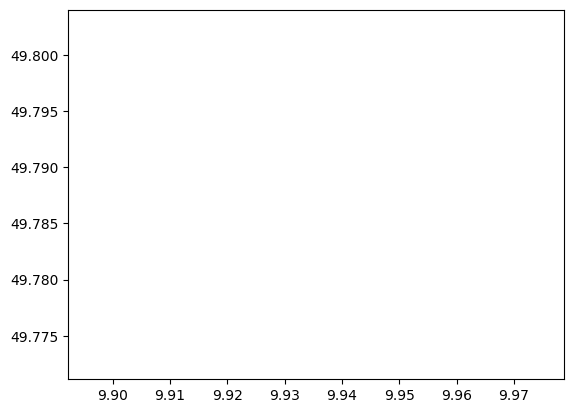

In [5]:
from gpt_morpho_analysis import create_pollution_heatmap


map = create_pollution_heatmap(measurements, buildings_gdf=buildings, output_path="pollution_heatmap.html")

In [3]:
measurements["svf_ray"].mean()

np.float64(0.840474659555349)

In [3]:
from gpt_morpho_analysis import create_svf_vs_pollution_plot
import os

create_svf_vs_pollution_plot(
        measurements, os.path.join("./results/particleBottom", "svf_ray_vs_pollution_cohensd.png")
)

✓ Scatter plots saved to ./results/particleBottom/svf_ray_vs_pollution_cohensd.png


In [9]:
measurements

,particles_mean_Particles > 0.3um / 0.1L air_particleBottom,particles_mean_Particles > 0.5um / 0.1L air_particleBottom,particles_mean_Particles > 1.0um / 0.1L air_particleBottom,particles_mean_Particles > 10.0um / 0.1L air_particleBottom,particles_mean_Particles > 2.5um / 0.1L air_particleBottom,particles_mean_Particles > 5.0um / 0.1L air_particleBottom,ultrafine_ufp,pm25_equiv,nearest_building_height,nearest_building_distance,mean_20nn_building_height,max_20nn_building_height,street_canyon_index,sky_view_factor,building_surface_fraction,building_density,mean_building_height_in_buffer,median_building_height_in_buffer,svf_ray,geometry
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.363177,0.636823,NaN,1.132184,1.017577,0.981329,POINT (570449.85 5515440.104)
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.272563,0.727437,NaN,1.231668,1.180276,0.986149,POINT (570449.887 5515490.104)
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.188029,29.650266,1.188029,1.188029,NaN,0.790911,0.209089,NaN,1.540494,1.540494,0.977943,POINT (570448.265 5515539.933)
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.855093,0.144907,NaN,2.977714,2.977714,0.985855,POINT (570412.023 5515567.509)
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.304796,23.476240,2.304796,2.304796,NaN,0.909636,0.090364,NaN,4.115567,4.767399,0.969323,POINT (570362.504 5515573.815)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6655,1363.6875,388.937500,36.875000,0.000000,0.000000,0.000000,596.500000,0.000000,NaN,NaN,NaN,NaN,NaN,0.926345,0.073655,NaN,3.789651,3.789651,0.989670,POINT (570356.353 5515603.568)
6656,1105.5000,329.852941,39.176471,0.000000,0.529412,0.000000,491.509804,0.176471,NaN,NaN,NaN,NaN,NaN,0.983291,0.016709,NaN,4.767399,4.767399,0.989928,POINT (570401.42 5515593.682)
6657,1062.8750,324.104167,47.812500,0.000000,2.791667,0.000000,478.263889,0.930556,NaN,NaN,NaN,NaN,NaN,0.774202,0.225798,NaN,2.616129,1.892960,0.986047,POINT (570426.529 5515561.995)
6658,973.6500,303.775000,35.900000,0.250000,2.850000,0.250000,437.775000,1.116667,1.188029,23.927639,1.188029,1.188029,NaN,0.426719,0.573281,NaN,1.417837,1.188029,0.974389,POINT (570450.876 5515523.027)
